<a href="https://colab.research.google.com/github/Didac-Ortega/proyecto-IA/blob/main/entrenamiento_modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total de registros cargados: 649
Porcentaje de aprobados en el dataset: 492 de 649 (75.81%)

--- ENTRENANDO DECISION TREE (ÁRBOL ÚNICO) ---
Precisión del Árbol en Test: 0.99
Precisión Media del Árbol (Cross-Validation): 0.99 (+/- 0.02)

Analizando el impacto de la profundidad en el Árbol:
Profundidad: 1 -> Precisión: 0.92 (+/- 0.04)
Profundidad: 2 -> Precisión: 0.93 (+/- 0.04)
Profundidad: 3 -> Precisión: 0.97 (+/- 0.03)
Profundidad: 4 -> Precisión: 0.99 (+/- 0.02)
Profundidad: 5 -> Precisión: 0.99 (+/- 0.02)
Profundidad: 6 -> Precisión: 0.99 (+/- 0.02)
Profundidad: 7 -> Precisión: 0.99 (+/- 0.03)
Profundidad: 8 -> Precisión: 0.99 (+/- 0.02)
Profundidad: 9 -> Precisión: 0.99 (+/- 0.02)
Profundidad: 10 -> Precisión: 0.99 (+/- 0.02)
Profundidad: 11 -> Precisión: 0.99 (+/- 0.02)
Profundidad: 12 -> Precisión: 0.99 (+/- 0.02)
Profundidad: 13 -> Precisión: 0.99 (+/- 0.03)
Profundidad: 14 -> Precisión: 0.99 (+/- 0.02)
Profundidad: 15 -> Precisión: 0.99 (+/- 0.02)
Profundidad: 16 -> Precisión:

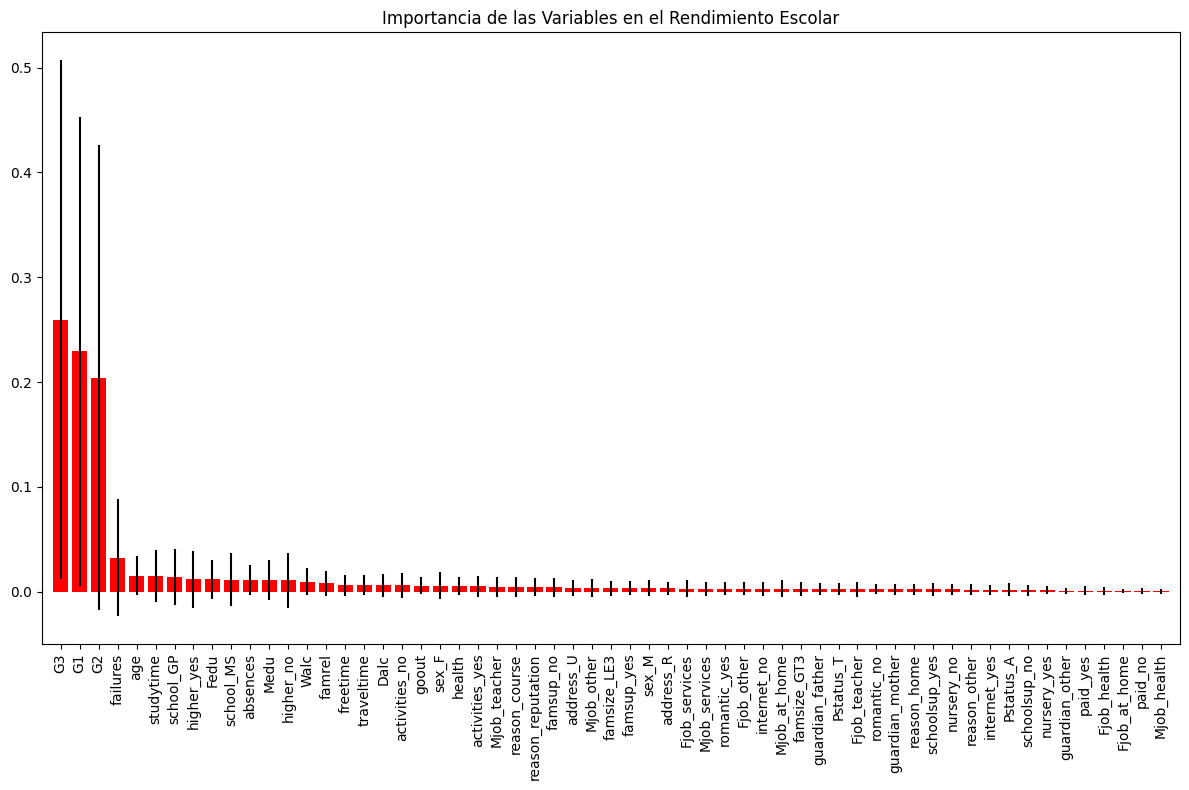


--- EXPORTACIÓN AUTOMÁTICA PARA TU WEB ---
¡Archivos binarios .joblib listos para descargar!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from google.colab import files

# 1. Cargar dataset original de Portugal
d = pd.read_csv('student-por.csv', sep=';')
print(f"Total de registros cargados: {len(d)}")

# 2. Generar etiqueta binaria (Aprobado si la suma de los 3 periodos es >= 30)
d['pass'] = d.apply(lambda row: 1 if (row['G1'] + row['G2'] + row['G3']) >= 30 else 0, axis=1)

# ¡CAMBIO CLAVE! NO eliminamos G1, G2 y G3 aquí para que el modelo aprenda de ellas
# d = d.drop(['G1', 'G2', 'G3'], axis=1) <- ESTA LÍNEA SE QUEDA ELIMINADA

# 3. Aplicar One-Hot Encoding a las variables cualitativas
# Convertimos todas de golpe de forma automática y limpia
d = pd.get_dummies(d)

# 4. Mezclar registros de forma aleatoria
d = d.sample(frac=1, random_state=42)

# 5. Dividir los datos en Entrenamiento (500) y Pruebas (Resto)
d_train = d[:500]
d_test = d[500:]

d_train_att = d_train.drop(['pass'], axis=1)
d_train_pass = d_train['pass']

d_test_att = d_test.drop(['pass'], axis=1)
d_test_pass = d_test['pass']

d_att = d.drop(['pass'], axis=1)
d_pass = d['pass']

# Mostrar estadísticas de aprobados totales
print("Porcentaje de aprobados en el dataset: %d de %d (%.2f%%)" % (np.sum(d_pass), len(d_pass), 100 * float(np.sum(d_pass)) / len(d_pass)))

print("\n--- ENTRENANDO DECISION TREE (ÁRBOL ÚNICO) ---")
# Entrenamos el árbol clásico con balanceo de pesos para evitar sesgos optimistas
t = tree.DecisionTreeClassifier(criterion="entropy", max_depth=5, class_weight="balanced")
t = t.fit(d_train_att, d_train_pass)

# Guardar la estructura del árbol en formato .dot para tu informe gráfico
tree.export_graphviz(t, out_file="student-performance.dot",
                     label="all", impurity=False, proportion=True,
                     feature_names=list(d_train_att), class_names=["fail", "pass"],
                     filled=True, rounded=True)

print(f"Precisión del Árbol en Test: {t.score(d_test_att, d_test_pass):.2f}")

# Validación cruzada del árbol
scores = cross_val_score(t, d_att, d_pass, cv=5)
print("Precisión Media del Árbol (Cross-Validation): %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))

# Tu bucle de investigación para analizar profundidades
print("\nAnalizando el impacto de la profundidad en el Árbol:")
for max_depth in range(1, 20):
    t_test = tree.DecisionTreeClassifier(criterion="entropy", max_depth=max_depth, class_weight="balanced")
    test_scores = cross_val_score(t_test, d_att, d_pass, cv=5)
    print("Profundidad: %d -> Precisión: %0.2f (+/- %0.2f)" % (max_depth, test_scores.mean(), test_scores.std() * 2))


print("\n--- ENTRENANDO RANDOM FOREST (BOSQUE INTELIGENTE) ---")
# Creamos el Random Forest definitivo que usará la Web de Streamlit
rf = RandomForestClassifier(n_estimators=100, criterion="entropy", max_depth=7, class_weight="balanced", random_state=42)
rf = rf.fit(d_train_att, d_train_pass)

print(f"Precisión del Random Forest en Test: {rf.score(d_test_att, d_test_pass):.2f}")

rf_scores = cross_val_score(rf, d_att, d_pass, cv=5)
print("Precisión Media del Random Forest (Cross-Validation): %0.2f (+/- %0.2f)" % (rf_scores.mean(), rf_scores.std() * 2))


print("\n--- GENERANDO GRÁFICA DE IMPORTANCIA DE VARIABLES ---")
importances = rf.feature_importances_
std = np.std([tree_item.feature_importances_ for tree_item in rf.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

print("Ranking de variables más determinantes para la IA:")
for f in range(10): # Mostramos el Top 10 en texto para no colapsar la pantalla
    print("%d. Variable: %s (%f)" % (f + 1, d_train_att.columns[indices[f]], importances[indices[f]]))

# Dibujar la gráfica de barras original de tu libro
plt.figure(figsize=(12, 8))
plt.title("Importancia de las Variables en el Rendimiento Escolar")
plt.bar(range(d_train_att.shape[1]), importances[indices], color="r", yerr=std[indices], align="center")
plt.xticks(range(d_train_att.shape[1]), d_train_att.columns[indices], rotation=90)
plt.xlim([-1, d_train_att.shape[1]])
plt.tight_layout()
plt.show()


print("\n--- EXPORTACIÓN AUTOMÁTICA PARA TU WEB ---")
# Guardamos la lista exacta de columnas que generó el get_dummies
model_columns = list(d_train_att.columns)
joblib.dump(model_columns, 'model_columns.joblib')

# Guardamos el modelo entrenado
joblib.dump(rf, 'modelo_arbol.joblib')
print("¡Archivos binarios .joblib listos para descargar!")

# Descarga automática directa al navegador para que los subas a GitHub
files.download('modelo_arbol.joblib')
files.download('model_columns.joblib')